In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.metrics import mean_squared_error

from pyro.infer import Predictive

from ssvs_class import BayesianSSVS
from utils import DataGenerator, Reservoir

import warnings
warnings.filterwarnings("ignore")

/Users/giacomogasparotto/POD/Bayesian-Inference-in-High-Dimensional-Reservoir-Dynamics-for-Neural-Time-Series/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===========================================================
# GLOBAL PLOT STYLE 
# Note: Requires a working LaTeX installation on your system
# ===========================================================

plt.rcParams.update({
    # LaTeX and Fonts
    "text.usetex": True,
    "font.family": "cmr10",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.size": 20,         
    "axes.titlesize": 20,      
    "axes.labelsize": 20,      
    "legend.fontsize": 20,    
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,

    # Line widths
    "axes.linewidth": 1.2,     
    "lines.linewidth": 1.5,    
    "lines.markersize": 8,    

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Grid
    # "axes.grid": True,
    # "grid.linestyle": "dashed",
    # "grid.alpha": 0.2,

    # Legend
    "legend.frameon": False,
    "legend.loc": "best"
    })

# Mackey-Glass dataset analysis

Test Mackey-Glass dataset

Input shape: (840, 1)
Reservoir States shape: (740, 500)


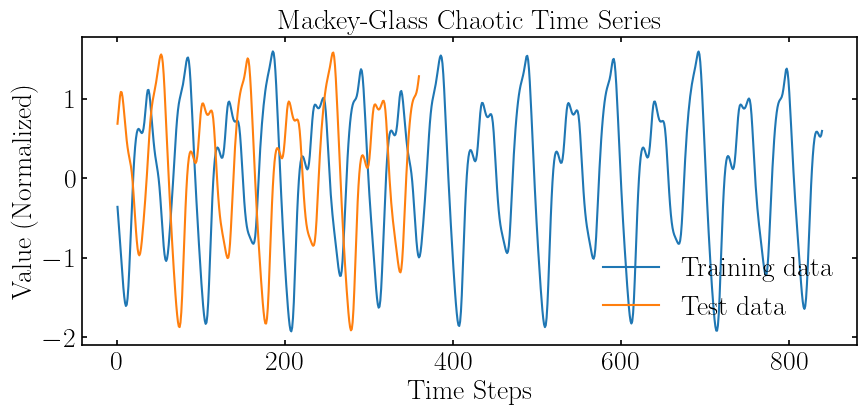

In [3]:
print("Test Mackey-Glass dataset\n")

# Data parameters
Time_steps = 14000
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()

# Clean dataset 
washout = 2000
X = X[washout:]
Y = Y[washout:]  

X = X[::10]
Y = Y[::10]

# Split Train e Test
train_points = int(len(X) * 0.7)

X_train = X[:train_points, :]
Y_train = Y[:train_points, :] 

X_test = X[train_points:, :]
Y_test = Y[train_points:, :]  

# Reservoir
res = Reservoir(input_dim=1, reservoir_dim=500, spectral_radius=0.9, seed=42)
S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

burnin = 100

S_train = S_train[burnin:, :]
Y_train = Y_train[burnin:, :]

S_test = S_test[burnin:, :]
Y_test = Y_test[burnin:, :]

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train, label="Training data")
plt.plot(X_test, label="Test data")

plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.legend(loc="best", frameon=False)
plt.show()

# Convert data in tensors
Xtrain_t = torch.tensor(S_train, dtype=torch.float32)
Ytrain_t = torch.tensor(Y_train, dtype=torch.float32)
Xtest_t = torch.tensor(S_test, dtype=torch.float32)
Ytest_t = torch.tensor(Y_test, dtype=torch.float32)

In [4]:
# Instantiate the object
mg_model = BayesianSSVS()

# Train the model
mg_model.train(Xtrain_t, Ytrain_t, epochs=2000, lr=0.01)

SSVS Training (via SVI) started for 2000 epochs (LR=0.01)...
Epoch 500/2000 - ELBO Loss: 1617.7577
Epoch 1000/2000 - ELBO Loss: 1588.1499
Epoch 1500/2000 - ELBO Loss: 1448.4051
Epoch 2000/2000 - ELBO Loss: 1325.9523


(AutoDiagonalNormal(),
 [4022.672188103199,
  3725.7531147003174,
  3876.27550239861,
  3817.635878920555,
  3786.0781039595604,
  3725.9634004831314,
  3895.876302614808,
  3853.591955423355,
  3738.549154996872,
  3712.49359574914,
  3776.254733964801,
  3639.1462509036064,
  3647.8715302348137,
  3762.2895012795925,
  3603.3727865219116,
  3554.2003496587276,
  3541.5390082001686,
  3638.4389703273773,
  3504.9772505164146,
  3550.2420155406,
  3747.0813593268394,
  3629.942548364401,
  3479.0257118940353,
  3453.4098699092865,
  3587.339405655861,
  3618.0951726436615,
  3466.9884865880013,
  3327.203562259674,
  3367.3288996219635,
  3382.373977661133,
  3571.6016801297665,
  3368.522644340992,
  3319.8145890831947,
  3384.494963914156,
  3330.819024860859,
  3327.8393620848656,
  3228.499397277832,
  3306.628400027752,
  3190.682191312313,
  3160.7633295059204,
  3207.4016298651695,
  3159.365070581436,
  3271.3564870357513,
  3156.786627829075,
  3141.1960968971252,
  3229.27078

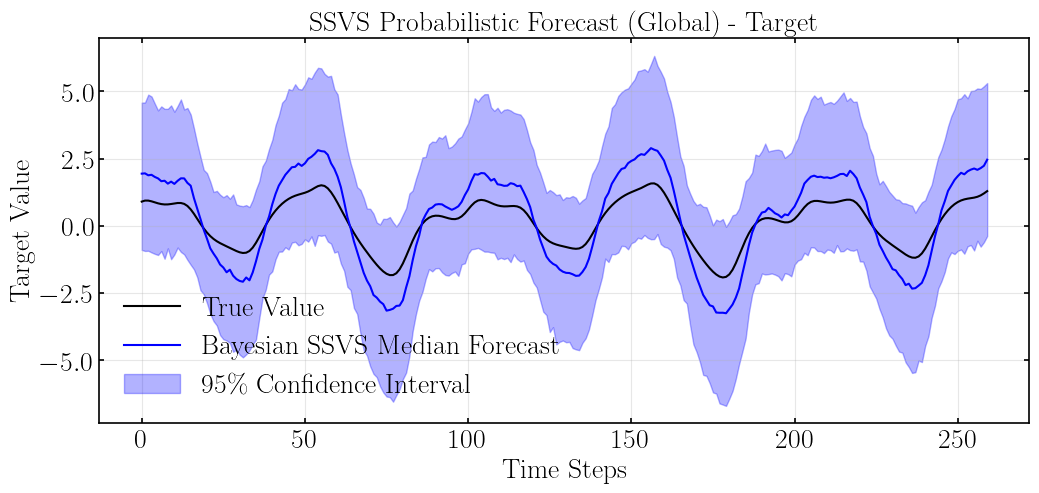

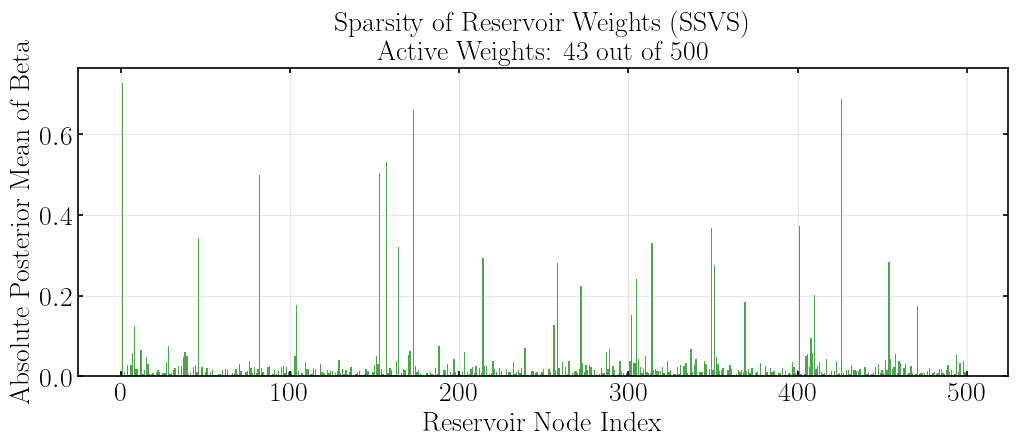


Generating Zoomed Plots...


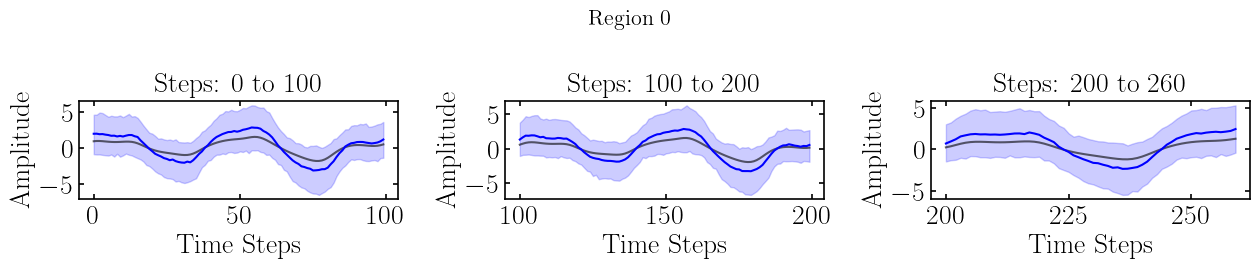

In [5]:
# Evaluate the model
mg_model.evaluate(Xtest_t, Ytest_t)

In [6]:
mg_metrics = mg_model.compute_metrics(Xtest_t, Ytest_t)

# Extract metrics
mg_mse = mg_metrics["mse"]
mg_coverage = mg_metrics["coverage"]
mg_width = mg_metrics["width"]
mg_calibration_error = mg_metrics["calibration_error"]
mg_mcrps = mg_metrics["mcrps"]


METRICS (Bayesian SSVS/SVI)
1. MSE (on median):           0.6354
2. Coverage (95% CI):         100.00%
3. Mean Width (95% CI):       5.4620
4. Calibration Error (cal):   0.0826
5. mCRPS (approximated):      0.3830



# fMRI dataset analysis

In [7]:
print("Loading and preprocessing data for fMRI...")

# 1. Caricamento file .mat (Assicurati che i path siano corretti per la tua cartella)
# Se i file sono dentro una cartella "real_data", aggiungi "real_data/" prima del nome
train_mat = sio.loadmat("100307.REST1.LR.SchaeferS.ptseries.mat")
test_mat = sio.loadmat("100307.REST2.LR.SchaeferS.ptseries.mat")

# 2. Estrazione e trasposizione: da [119, 1200] a [1200, 119]
train_data = train_mat["tseries"].T
test_data = test_mat["tseries"].T

# 3. Standardizzazione (Fondamentale!)
scaler = StandardScaler()
# Fit e transform sul train, SOLO transform sul test
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# 4. Preparazione X (input al tempo t) e Y (target al tempo t+1)
target_reg = 0  # Prevediamo la regione 0. Puoi cambiarla per testarne altre!

X_tr_fmri = train_scaled[:-1, :]
Y_tr_fmri = train_scaled[1:, target_reg].reshape(-1, 1)

X_ts_fmri = test_scaled[:-1, :]
Y_ts_fmri = test_scaled[1:, target_reg].reshape(-1, 1)

print(f"Shape X_train: {X_tr_fmri.shape}, Shape Y_train: {Y_tr_fmri.shape}")
print(f"Shape X_test:  {X_ts_fmri.shape}, Shape Y_test:  {Y_ts_fmri.shape}")

Loading and preprocessing data for fMRI...
Shape X_train: (1199, 119), Shape Y_train: (1199, 1)
Shape X_test:  (1199, 119), Shape Y_test:  (1199, 1)


In [8]:
# Define grid search parameters
param_grid = {
    "learning_rate": [0.001, 0.01, 0.05, 0.1],      
    "epochs": [2000, 3000],                  
    "spectral_radius": [0.5, 0.8, 0.9, 0.99]            
}

burnin = 100 

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_mse = float('inf')
best_params = None
best_model = None 

X_tr_numpy = X_tr_fmri
Y_tr_numpy = Y_tr_fmri
X_ts_numpy = X_ts_fmri
Y_ts_numpy = Y_ts_fmri

print("STARTING GRID SEARCH...")
for idx, config in enumerate(combinations):
    print(f"\n[{idx+1}/{len(combinations)}] Test Config: {config}")
    
    lr = config["learning_rate"]
    ep = config["epochs"]
    sr = config["spectral_radius"]
    
    try:
        res_grid = Reservoir(input_dim=119, reservoir_dim=500, spectral_radius=sr, seed=42)
        
        # Create reservoir states
        S_train_raw = res_grid.get_states(X_tr_numpy)[burnin:, :]
        Y_tr_burned = Y_tr_numpy[burnin:, :]
        
        S_test_raw = res_grid.get_states(X_ts_numpy)[burnin:, :]
        Y_ts_burned = Y_ts_numpy[burnin:, :]
        
        # Convert in tensor
        X_tr_t = torch.tensor(S_train_raw, dtype=torch.float32)
        Y_tr_t = torch.tensor(Y_tr_burned, dtype=torch.float32)
        X_ts_t = torch.tensor(S_test_raw, dtype=torch.float32)
        
        # Instantiate the object
        current_model = BayesianSSVS()
        
        # Train the model
        current_model.train(X_tr_t, Y_tr_t, epochs=ep, lr=lr)
        
        # Compute the mse for evaluation
        predictive = Predictive(current_model.model, guide=current_model.guide, num_samples=300, return_sites=("obs",))
        y_pred_samples = predictive(X_ts_t)["obs"]
        y_pred_mean = torch.median(y_pred_samples, dim=0).values.detach().numpy()
        
        current_mse = mean_squared_error(Y_ts_burned, y_pred_mean)
        
        print(f"Test MSE: {current_mse:.4f}")
        
        if current_mse < best_mse:
            best_mse = current_mse
            best_params = config
            best_model = current_model 
            print(f"NEW BEST MODEL FOUND!")
            
    except Exception as e:
        print(f"Error with this configuration: {e}")

print("\n FINAL RESULTS:")
print("\n" + "="*50)
print(f"GRID SEARCH COMPLETED!")
print(f"Best parameters: {best_params}")
print(f"Best MSE: {best_mse:.4f}")
print("="*50)

STARTING GRID SEARCH...

[1/32] Test Config: {'learning_rate': 0.001, 'epochs': 2000, 'spectral_radius': 0.5}
SSVS Training (via SVI) started for 2000 epochs (LR=0.001)...
Epoch 500/2000 - ELBO Loss: 5108.8983
Epoch 1000/2000 - ELBO Loss: 4431.7418
Epoch 1500/2000 - ELBO Loss: 4078.1326
Epoch 2000/2000 - ELBO Loss: 3812.7970
Test MSE: 37.2666
NEW BEST MODEL FOUND!

[2/32] Test Config: {'learning_rate': 0.001, 'epochs': 2000, 'spectral_radius': 0.8}
SSVS Training (via SVI) started for 2000 epochs (LR=0.001)...
Epoch 500/2000 - ELBO Loss: 3786.1367
Epoch 1000/2000 - ELBO Loss: 3132.1041
Epoch 1500/2000 - ELBO Loss: 2896.5191
Epoch 2000/2000 - ELBO Loss: 2606.4565
Test MSE: 2.4005
NEW BEST MODEL FOUND!

[3/32] Test Config: {'learning_rate': 0.001, 'epochs': 2000, 'spectral_radius': 0.9}
SSVS Training (via SVI) started for 2000 epochs (LR=0.001)...
Epoch 500/2000 - ELBO Loss: 4592.9252
Epoch 1000/2000 - ELBO Loss: 3955.0940
Epoch 1500/2000 - ELBO Loss: 3515.0322
Epoch 2000/2000 - ELBO Loss

In [9]:
# Build the reservoir with the best parameters
best_res = Reservoir(input_dim=119, reservoir_dim=500, spectral_radius=best_params["spectral_radius"], seed=42)
S_test_best = best_res.get_states(X_ts_numpy)[burnin:, :]
Y_ts_best = Y_ts_numpy[burnin:, :]

# Convert in tensor
X_test_best_t = torch.tensor(S_test_best, dtype=torch.float32)
Y_test_t = torch.tensor(Y_ts_best, dtype=torch.float32)

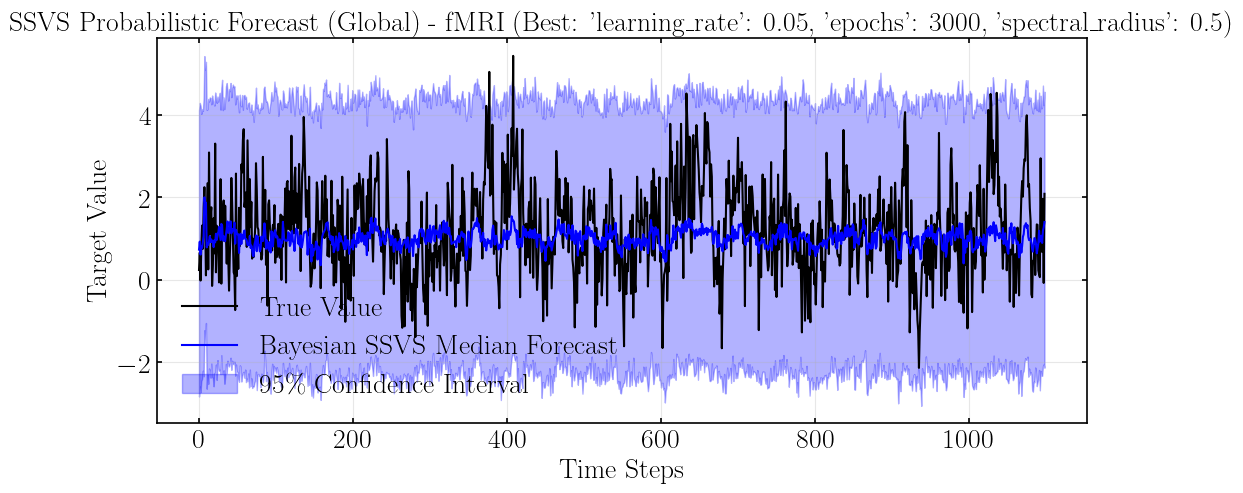

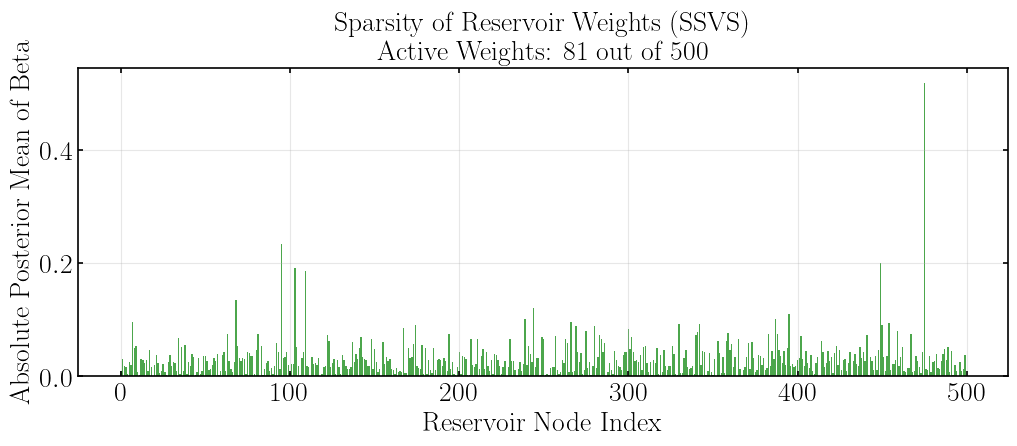


Generating Zoomed Plots...


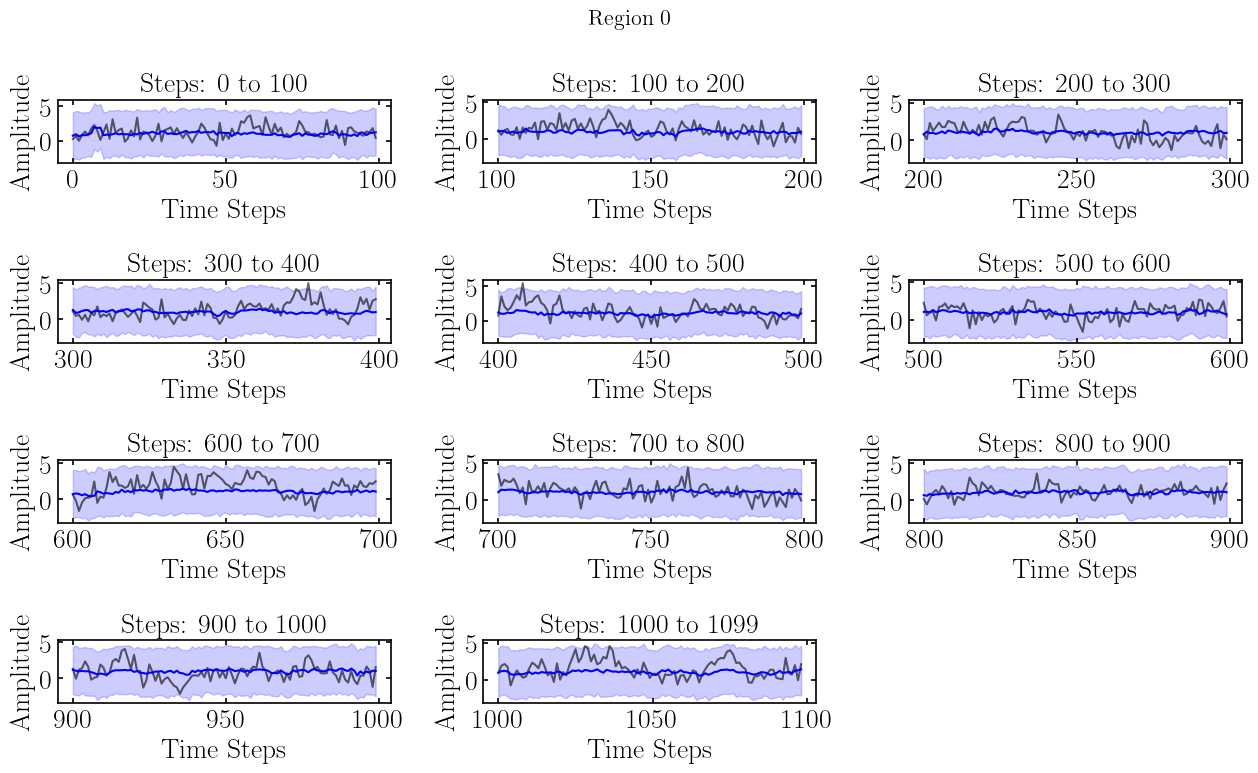

In [10]:
best_model.evaluate(X_test_best_t, Y_test_t, num_samples=1000, target_name=f"fMRI (Best: {best_params})")

In [11]:
final_metrics = best_model.compute_metrics(X_test_best_t, Y_test_t, num_samples=1000)

# Extract metrics for fMRI
fmri_mse = final_metrics["mse"]
fmri_coverage = final_metrics["coverage"]
fmri_width = final_metrics["width"]
fmri_calibration_error = final_metrics["calibration_error"]
fmri_mcrps = final_metrics["mcrps"]


METRICS (Bayesian SSVS/SVI)
1. MSE (on median):           1.2156
2. Coverage (95% CI):         99.55%
3. Mean Width (95% CI):       6.6697
4. Calibration Error (cal):   0.0522
5. mCRPS (approximated):      0.5182

